# Multi-route pedestrian mobility analysis
## Zona Universitària, Barcelona — June 2026

**Pipeline:** GPX → stop detection (Larroya et al. Δt≥10s, single-point episodes valid)
→ DBSCAN clustering → MSD (median-dt time axis) → log-velocity ACF → velocity collapse → figure A/B/C/D.

**Reference:** Larroya, F., Paez, R., Valtchanova, M. and Perelló, J. *Explorative pedestrian mobility geolocated data from a citizen science experiment in a neighbourhood.* Sci Data **12**, 1036 (2025).

---

## 1. Imports

In [1]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
import gpxpy
from scipy.stats import gaussian_kde, kurtosis, skew
from sklearn.cluster import DBSCAN

try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print("⚠️  contextily not installed (pip install contextily) — Panel A will lack basemap")

import warnings; warnings.filterwarnings('ignore')
print("✅ Libraries loaded")

c:\Users\PC\.anaconda\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Libraries loaded


## 2. Helper functions (corrected)

Two key fixes vs. earlier drafts:
- **`detect_stops`** keeps single-point Larroya episodes (a long Δt at one record IS a valid stop).
- **`compute_msd`** uses `median Δt × lag` for the time axis, so MSD starts at ~4–5 s (the GPS sampling cadence), not inflated by long pauses.

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6_371_000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2-lat1), math.radians(lon2-lon1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2*R*math.atan2(math.sqrt(a), math.sqrt(1-a))


def parse_gpx(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        gpx = gpxpy.parse(f)
    pts = []
    for tr in gpx.tracks:
        for seg in tr.segments:
            for pt in seg.points:
                pts.append({'lat': pt.latitude, 'lon': pt.longitude,
                            'ele': pt.elevation, 'time': pt.time})
    if not pts: return None
    df = pd.DataFrame(pts)
    df['time'] = pd.to_datetime(df['time'])
    dists, dts = [0.0], [0.0]
    for i in range(1, len(df)):
        dists.append(haversine(df.iloc[i-1]['lat'], df.iloc[i-1]['lon'],
                               df.iloc[i]['lat'],   df.iloc[i]['lon']))
        dts.append((df.iloc[i]['time'] - df.iloc[i-1]['time']).total_seconds())
    df['step_length_m']     = dists
    df['dt_s']              = dts
    df['speed_ms']          = df['step_length_m']/df['dt_s'].replace(0, np.nan)
    df['speed_ms']          = df['speed_ms'].fillna(0)
    df['cumulative_dist_m'] = df['step_length_m'].cumsum()
    df['elapsed_min']       = (df['time']-df['time'].iloc[0]).dt.total_seconds()/60
    return df


def label_stops(df, dt_threshold=10.0):
    """Larroya et al. (2025): record i is 'stop' if Δt_forward(i) ≥ 10 s."""
    df = df.copy()
    df['dt_forward'] = df['dt_s'].shift(-1)
    df['movement']   = np.where(df['dt_forward'] >= dt_threshold, 'stop', 'moving')
    df.loc[df.index[-1], 'movement'] = np.nan
    return df


def detect_stops(df, dt_threshold=10.0, min_duration=60.0, r_thresh=50.0):
    """
    Detect stop EPISODES (groups of consecutive 'stop' labels).
    A single 'stop' record IS valid: it represents a pause of dt_forward seconds.
    Filters: total duration ≥ min_duration and spatial radius ≤ r_thresh.
    """
    df2 = label_stops(df, dt_threshold)
    is_stop = (df2['movement'] == 'stop').values
    episodes = []
    i = 0
    while i < len(is_stop):
        if is_stop[i]:
            start = i
            while i < len(is_stop) and is_stop[i]:
                i += 1
            end = i - 1
            next_idx = min(end + 1, len(df2) - 1)
            episodes.append((start, end, next_idx))
        else:
            i += 1

    stops = []
    for (s, e, ne) in episodes:
        t_start = df2.iloc[s]['time']
        t_end   = df2.iloc[ne]['time']
        dur     = (t_end - t_start).total_seconds()
        if dur < min_duration: continue
        seg = df2.iloc[s:e+1]
        clat, clon = seg['lat'].mean(), seg['lon'].mean()
        if len(seg) > 1:
            max_r = seg.apply(
                lambda r: haversine(clat, clon, r['lat'], r['lon']), axis=1
            ).max()
        else:
            max_r = 0.0
        if max_r > r_thresh: continue
        stops.append({'start_idx':s, 'end_idx':e,
                      'start_time':t_start, 'end_time':t_end,
                      'duration_s':dur, 'duration_min':dur/60,
                      'n_points':len(seg),
                      'centroid_lat':clat, 'centroid_lon':clon,
                      'radius_m':max_r})
    return pd.DataFrame(stops)


def compute_msd(df, max_lag=80):
    """MSD(τ) using median Δt for the time axis (robust to long pauses)."""
    pts   = df[['lat','lon']].values
    n     = len(df)
    max_lag = min(max_lag, n//3)
    median_dt = df['dt_s'].iloc[1:].median()

    msd_v = []
    for lag in range(1, max_lag):
        sq = [haversine(pts[i,0], pts[i,1], pts[i+lag,0], pts[i+lag,1])**2
              for i in range(n-lag)]
        msd_v.append(np.mean(sq))
    lt = np.arange(1, max_lag) * median_dt
    msd_v = np.array(msd_v)
    mask = (lt > 0) & (msd_v > 0)
    c = np.polyfit(np.log10(lt[mask]), np.log10(msd_v[mask]), 1)
    return lt, msd_v, c[0]


def log_v_acf(traj, max_lag_samples=50, eps=0.05):
    v = traj['speed_ms'].iloc[1:].values
    v_filt = v[v > eps]
    n = len(v_filt)
    if n < 20: return None
    logv = np.log(v_filt); logv = logv - logv.mean()
    var = np.var(logv)
    if var == 0: return None
    max_lag = min(max_lag_samples, n//4)
    lags = np.arange(0, max_lag)
    acf = np.array([np.mean(logv[:n-k]*logv[k:])/var for k in lags])
    median_dt = traj['dt_s'].iloc[1:].median()
    return lags*median_dt, acf, 1.96/np.sqrt(n), n


print("✅ Functions defined")

✅ Functions defined


## 3. Load all GPX files

In [3]:
GPX_FOLDER = 'C:\\Users\\PC\\Desktop\\MASTER\\segundo cuatri\\socio_eco\\DataMobility\\'
files = sorted(glob.glob(os.path.join(GPX_FOLDER, '*.gpx')))
print(f"Found {len(files)} GPX files")

trajectories = {}
for fp in files:
    name = os.path.splitext(os.path.basename(fp))[0]
    traj = parse_gpx(fp)
    if traj is not None and len(traj) > 20:
        trajectories[name] = traj
        print(f"  {name}: {len(traj):>4} pts, "
              f"{traj['elapsed_min'].iloc[-1]:5.1f} min, "
              f"{traj['cumulative_dist_m'].iloc[-1]:5.0f} m, "
              f"median Δt = {traj['dt_s'].iloc[1:].median():.1f}s")

N_GROUPS = len(trajectories)
print(f"\n✅ {N_GROUPS} trajectories loaded")

Found 4 GPX files
  PolAnderRuta:  280 pts,  44.3 min,  1807 m, median Δt = 4.0s
  josep:  304 pts,  36.5 min,  1722 m, median Δt = 5.0s
  pau-gargallo:  288 pts,  37.2 min,  1766 m, median Δt = 5.0s
  zona-universitaria-pqs:  510 pts,  48.8 min,  3113 m, median Δt = 4.0s

✅ 4 trajectories loaded


## 4. Detect stops (Larroya et al. method)

In [4]:
all_stops = []
for name, traj in trajectories.items():
    s = detect_stops(traj, dt_threshold=10.0, min_duration=60.0, r_thresh=50.0)
    if len(s):
        s['group'] = name
        all_stops.append(s)
    n_pts = (label_stops(traj)['movement']=='stop').sum()
    print(f"  {name}: {len(s) if len(s) else 0} episodes "
          f"(from {n_pts} stop-labeled records)")

all_stops_df = pd.concat(all_stops, ignore_index=True)
print(f"\nTotal episodes: {len(all_stops_df)}")
print(f"Durations (min): {sorted(all_stops_df['duration_min'].round(1).tolist())}")

  PolAnderRuta: 4 episodes (from 24 stop-labeled records)
  josep: 6 episodes (from 20 stop-labeled records)
  pau-gargallo: 2 episodes (from 32 stop-labeled records)
  zona-universitaria-pqs: 5 episodes (from 29 stop-labeled records)

Total episodes: 17
Durations (min): [1.1, 1.1, 1.1, 1.1, 1.2, 1.2, 1.4, 1.5, 1.7, 1.8, 1.9, 2.3, 3.3, 4.1, 4.4, 6.0, 13.2]


## 5. DBSCAN spatial clustering

In [5]:
LAT_TO_M = 111_320
LON_TO_M = 111_320 * np.cos(np.radians(41.385))
lon_ref  = all_stops_df['centroid_lon'].mean()
lat_ref  = all_stops_df['centroid_lat'].mean()
all_stops_df['x_m'] = (all_stops_df['centroid_lon'] - lon_ref) * LON_TO_M
all_stops_df['y_m'] = (all_stops_df['centroid_lat'] - lat_ref) * LAT_TO_M

X = all_stops_df[['x_m','y_m']].values
db = DBSCAN(eps=40, min_samples=2).fit(X)
all_stops_df['cluster_dbscan'] = db.labels_

n_cl    = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"DBSCAN: {n_cl} clusters, {n_noise} noise points\n")

for lbl in sorted(set(db.labels_)):
    if lbl == -1: continue
    m = db.labels_ == lbl
    sub = all_stops_df[m]
    grps = sorted(sub['group'].unique())
    print(f"  C{lbl+1}: {m.sum()} stops, {len(grps)} groups, "
          f"{sub['duration_s'].sum()/60:.1f} min total\n      groups = {grps}")

DBSCAN: 2 clusters, 10 noise points

  C1: 4 stops, 3 groups, 9.0 min total
      groups = ['PolAnderRuta', 'pau-gargallo', 'zona-universitaria-pqs']
  C2: 3 stops, 1 groups, 9.2 min total
      groups = ['josep']


## 6. MSD per trajectory

In [6]:
msd_results = {}
for name, traj in trajectories.items():
    lt, mv, alpha = compute_msd(traj)
    msd_results[name] = {'lt':lt, 'msd':mv, 'alpha':alpha}
    print(f"  {name:35s} α = {alpha:.3f},  lt[0] = {lt[0]:.1f}s")

alphas = [r['alpha'] for r in msd_results.values()]
print(f"\n→ Mean α = {np.mean(alphas):.3f} ± {np.std(alphas):.3f}")

  PolAnderRuta                        α = 1.499,  lt[0] = 4.0s
  josep                               α = 1.619,  lt[0] = 5.0s
  pau-gargallo                        α = 1.322,  lt[0] = 5.0s
  zona-universitaria-pqs              α = 1.669,  lt[0] = 4.0s

→ Mean α = 1.527 ± 0.133


## 7. log-velocity ACF per trajectory

In [7]:
acf_results = {}
for name, traj in trajectories.items():
    res = log_v_acf(traj, max_lag_samples=50)
    if res is None: continue
    tau, acf, ci, n = res
    acf_results[name] = {'tau':tau, 'acf':acf, 'ci':ci, 'n':n}
    below = np.where(acf < ci)[0]
    tau_c = tau[below[0]] if len(below) else tau[-1]
    print(f"  {name:35s} n={n:4d}  τ_corr ≥ {tau_c:.0f}s  (CI=±{ci:.3f})")

  PolAnderRuta                        n= 275  τ_corr ≥ 16s  (CI=±0.118)
  josep                               n= 301  τ_corr ≥ 45s  (CI=±0.113)
  pau-gargallo                        n= 287  τ_corr ≥ 15s  (CI=±0.116)
  zona-universitaria-pqs              n= 509  τ_corr ≥ 12s  (CI=±0.087)


## 8. Essay figure A/B/C/D

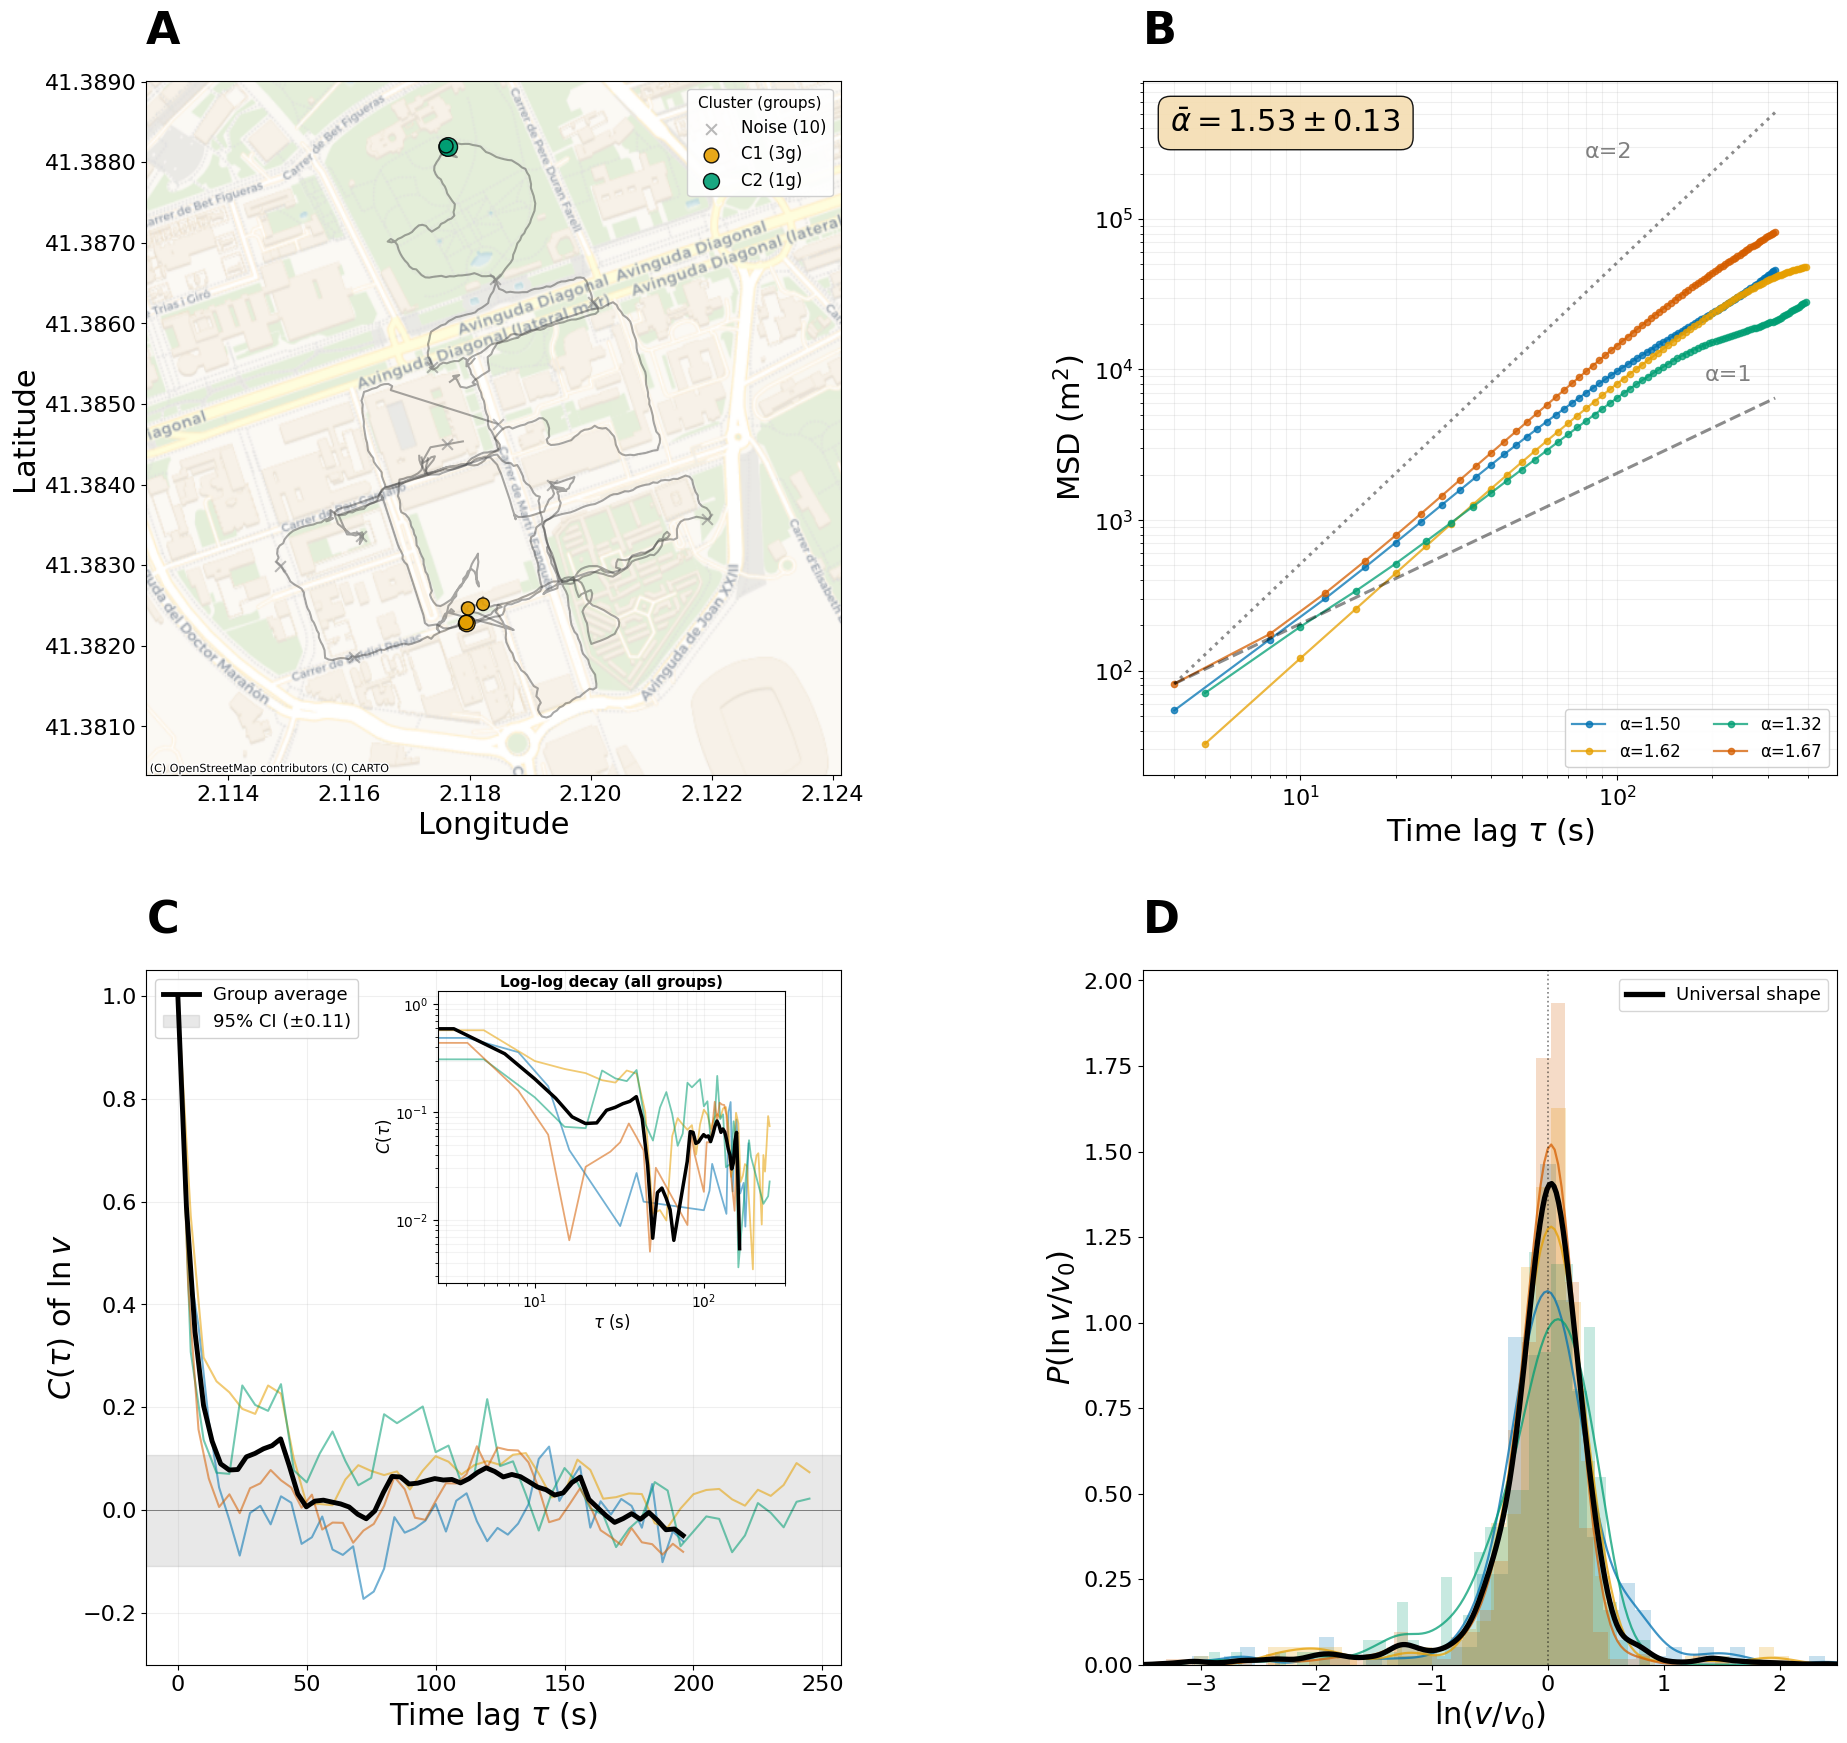

✅ figure_essay_final.png saved


In [9]:
plt.rcParams.update({
    'font.size': 18, 'axes.labelsize': 22,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'figure.facecolor': 'white', 'font.family': 'sans-serif',
})
CB = ['#0072B2', '#E69F00', '#009E73', '#D55E00',
      '#CC79A7', '#56B4E9', '#F0E442']
group_colors = (CB * (N_GROUPS // len(CB) + 1))[:N_GROUPS]

def panel_label(ax, letter):
    ax.text(0.0, 1.04, letter, transform=ax.transAxes,
            fontsize=32, fontweight='bold', va='bottom', ha='left')

fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(2, 2, hspace=0.28, wspace=0.24,
                       left=0.07, right=0.97, top=0.94, bottom=0.06)

# ── A: Map + DBSCAN as GEOGRAPHIC SQUARE ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, traj in trajectories.items():
    ax1.plot(traj['lon'], traj['lat'], '-', lw=1.5, alpha=0.45,
             color='#404040', zorder=2)

dbscan_labels = all_stops_df['cluster_dbscan'].values
for i, lbl in enumerate(sorted(set(dbscan_labels))):
    if lbl == -1:
        m = dbscan_labels == -1
        ax1.scatter(all_stops_df[m]['centroid_lon'], all_stops_df[m]['centroid_lat'],
                    s=60, c='gray', alpha=0.55, zorder=3, marker='x',
                    label=f'Noise ({m.sum()})')
    else:
        m = dbscan_labels == lbl
        ng = all_stops_df[m]['group'].nunique()
        sz = all_stops_df[m]['duration_s'].values / 3 + 60
        ax1.scatter(all_stops_df[m]['centroid_lon'], all_stops_df[m]['centroid_lat'],
                    s=sz, c=CB[i % len(CB)], edgecolors='k', linewidths=1.0,
                    alpha=0.9, zorder=4, label=f'C{lbl+1} ({ng}g)')

# Geographic-square limits centred on data
all_lats = pd.concat([t['lat'] for t in trajectories.values()])
all_lons = pd.concat([t['lon'] for t in trajectories.values()])
lon_c = (all_lons.max() + all_lons.min()) / 2
lat_c = (all_lats.max() + all_lats.min()) / 2
half_lat_m = (all_lats.max() - all_lats.min()) / 2 * 111_320
half_lon_m = (all_lons.max() - all_lons.min()) / 2 * 111_320 * np.cos(np.radians(lat_c))
half_m = max(half_lat_m, half_lon_m) + 80   # +80 m margin

half_lat_deg = half_m / 111_320
half_lon_deg = half_m / (111_320 * np.cos(np.radians(lat_c)))
ax1.set_xlim(lon_c - half_lon_deg, lon_c + half_lon_deg)
ax1.set_ylim(lat_c - half_lat_deg, lat_c + half_lat_deg)
ax1.set_aspect(1.0 / np.cos(np.radians(lat_c)))

if HAS_CTX:
    try:
        ctx.add_basemap(ax1, crs='EPSG:4326',
                        source=ctx.providers.CartoDB.Voyager,
                        zoom=16, alpha=0.85)
        ax1.set_xlim(lon_c - half_lon_deg, lon_c + half_lon_deg)
        ax1.set_ylim(lat_c - half_lat_deg, lat_c + half_lat_deg)
    except Exception as e:
        print(f"Basemap failed: {e}")

ax1.ticklabel_format(useOffset=False, style='plain', axis='both')
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
ax1.set_xlabel('Longitude'); ax1.set_ylabel('Latitude')
ax1.legend(fontsize=12, loc='upper right', ncol=1,
           framealpha=0.92, title='Cluster (groups)', title_fontsize=11)
ax1.set_box_aspect(1.0)
panel_label(ax1, 'A')

# ── B: MSD ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
saved_lt, saved_msd = None, None
for i, (name, r) in enumerate(msd_results.items()):
    ax2.loglog(r['lt'], r['msd'], 'o-', ms=4.5, lw=1.6, alpha=0.75,
               color=group_colors[i], label=f'α={r["alpha"]:.2f}')
    mask = (r['lt'] > 0) & (r['msd'] > 0)
    saved_lt, saved_msd = r['lt'][mask], r['msd'][mask]

t_lo, t_hi = saved_lt.min(), saved_lt.max()
msd_lo = saved_msd.min()
t_ref = np.array([t_lo, t_hi])
ax2.loglog(t_ref, msd_lo * (t_ref/t_lo)**1, 'k--', lw=2.2, alpha=0.45)
ax2.loglog(t_ref, msd_lo * (t_ref/t_lo)**2, 'k:',  lw=2.2, alpha=0.45)
ax2.text(t_hi*0.6,  msd_lo*(t_hi/t_lo)**1*1.3, 'α=1', fontsize=16, color='gray')
ax2.text(t_hi*0.25, msd_lo*(t_hi/t_lo)**2*0.5, 'α=2', fontsize=16, color='gray')

mean_a, std_a = np.mean(alphas), np.std(alphas)
ax2.text(0.04, 0.96, fr'$\bar{{\alpha}} = {mean_a:.2f} \pm {std_a:.2f}$',
         transform=ax2.transAxes, fontsize=22, fontweight='bold', va='top',
         bbox=dict(boxstyle='round,pad=0.4', fc='wheat', alpha=0.92))
ax2.set_xlabel(r'Time lag $\tau$ (s)'); ax2.set_ylabel(r'MSD (m$^2$)')
ax2.legend(fontsize=12, loc='lower right', ncol=2, framealpha=0.92)
ax2.grid(True, alpha=0.2, which='both')
ax2.set_box_aspect(1.0)
panel_label(ax2, 'B')

# ── C: ACF linear + log-log inset (ALL curves) ────────────────
ax3 = fig.add_subplot(gs[1, 0])
all_taus, all_acfs, all_cis = [], [], []
for i, (name, r) in enumerate(acf_results.items()):
    all_taus.append(r['tau']); all_acfs.append(r['acf']); all_cis.append(r['ci'])
    ax3.plot(r['tau'], r['acf'], '-', lw=1.5, alpha=0.55, color=group_colors[i])

tau_max_common = min(t.max() for t in all_taus)
common_tau = np.linspace(0, tau_max_common, 60)
acfs_interp = [np.interp(common_tau, t, a) for t, a in zip(all_taus, all_acfs)]
mean_acf = np.mean(acfs_interp, axis=0)
ax3.plot(common_tau, mean_acf, 'k-', lw=3.5, label='Group average', zorder=10)

mean_ci = np.mean(all_cis)
ax3.axhspan(-mean_ci, mean_ci, alpha=0.18, color='gray',
            label=f'95% CI (±{mean_ci:.2f})')
ax3.axhline(0, color='k', lw=0.6, alpha=0.5)
ax3.set_xlabel(r'Time lag $\tau$ (s)')
ax3.set_ylabel(r'$C(\tau)$ of $\ln v$')
ax3.legend(fontsize=13, loc='upper left', framealpha=0.9)
ax3.grid(True, alpha=0.2)
ax3.set_ylim(-0.3, 1.05)

# Inset (upper centre-right of panel C)
ax_inset = ax3.inset_axes([0.42, 0.55, 0.5, 0.42])
for i, (name, r) in enumerate(acf_results.items()):
    pos = r['acf'] > 0
    if pos.sum() > 2:
        ax_inset.loglog(r['tau'][pos], r['acf'][pos],
                        '-', lw=1.3, alpha=0.55, color=group_colors[i])
pos_mean = mean_acf > 0
ax_inset.loglog(common_tau[pos_mean], mean_acf[pos_mean],
                'k-', lw=2.5, zorder=10)
ax_inset.set_xlabel(r'$\tau$ (s)', fontsize=12, labelpad=1)
ax_inset.set_ylabel(r'$C(\tau)$', fontsize=12, labelpad=1)
ax_inset.tick_params(labelsize=10)
ax_inset.grid(True, alpha=0.15, which='both')
ax_inset.set_title('Log-log decay (all groups)', fontsize=11, fontweight='bold', pad=3)
ax3.set_box_aspect(1.0)
panel_label(ax3, 'C')

# ── D: Velocity collapse ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
all_rescaled = []
for i, (name, traj) in enumerate(trajectories.items()):
    spd = traj['speed_ms'].iloc[1:]; spd = spd[spd > 0.05]
    if len(spd) == 0: continue
    v0 = spd.median()
    y = np.log(spd / v0); y = y[np.isfinite(y)]
    all_rescaled.extend(y.tolist())
    ax4.hist(y, bins=40, density=True, alpha=0.22,
             color=group_colors[i], histtype='stepfilled')
    if len(y) > 5:
        kde = gaussian_kde(y, bw_method=0.3)
        xs = np.linspace(-3.5, 2.5, 200)
        ax4.plot(xs, kde(xs), lw=1.6, alpha=0.75, color=group_colors[i])

all_r = np.array([v for v in all_rescaled if np.isfinite(v)])
kde_all = gaussian_kde(all_r, bw_method=0.2)
xs = np.linspace(-3.5, 2.5, 300)
ax4.plot(xs, kde_all(xs), 'k-', lw=3.8, label='Universal shape')
ax4.axvline(0, color='k', ls=':', lw=1.2, alpha=0.5)

k_val, sk_val = kurtosis(all_r), skew(all_r)

ax4.set_xlabel(r'$\ln(v / v_0)$'); ax4.set_ylabel(r'$P(\ln v / v_0)$')
ax4.legend(fontsize=13, loc='upper right')
ax4.set_xlim(-3.5, 2.5)
ax4.set_box_aspect(1.0)
panel_label(ax4, 'D')

plt.savefig('figure_essay_final.png', dpi=240, bbox_inches='tight')
plt.show()
print('✅ figure_essay_final.png saved')